In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/pharvesh/resnet18-2/pytorch/default/1/gtsrb_resnet18.pth


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os, random

# ── Configuration — edit these to match your setup ──────────────────────────
CFG = dict(
    model_path    = "/kaggle/input/models/pharvesh/resnet18-2/pytorch/default/1/gtsrb_resnet18.pth",  # ← path to your trained model
    image_size    = 32,                # resize all images to this
    source_class  = 14,                # class we ATTACK  (14 = Stop sign)
    target_class  = 1,                 # desired wrong prediction (1 = 30 km/h)
    mask_type     = "rectangle",       # rectangle | circle | border | full
    mask_ratio    = 0.35,              # fraction of image covered by sticker
    epsilon       = 0.7,               # max L∞ perturbation per pixel
    alpha         = 0.01,              # Adam learning rate
    num_steps     = 500,               # optimisation iterations
    num_transforms= 10,                # physical transforms sampled per step
    lambda_tv     = 1e-4,              # smoothness regulariser weight
    lambda_lp     = 1e-3,              # L2 norm regulariser weight
    device        = "cuda" if torch.cuda.is_available() else "cpu",
    seed          = 42,
)

# Reproducibility
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
random.seed(CFG["seed"])

print("✓ Imports done")
print(f"  Device : {CFG['device']}")
print(f"  PyTorch: {torch.__version__}")

✓ Imports done
  Device : cuda
  PyTorch: 2.10.0+cu128


In [3]:
GTSRB_CLASSES = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
    "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
    "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
    "No passing", "No passing (>3.5t)", "Right-of-way at intersection",
    "Priority road", "Yield", "Stop", "No vehicles", "Vehicles >3.5t prohibited",
    "No entry", "General caution", "Dangerous curve left", "Dangerous curve right",
    "Double curve", "Bumpy road", "Slippery road", "Road narrows right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing",
    "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
    "End of all restrictions", "Turn right ahead", "Turn left ahead", "Ahead only",
    "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End of no passing", "End of no passing (>3.5t)",
]

transform = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),   # → (C, H, W) float in [0, 1],
    T.Normalize(mean=[0.3337, 0.3064, 0.3171],
                std =[0.2672, 0.2564, 0.2629]),  # GTSRB statistics
])





# Download=True will auto-download if not present
dataset = GTSRB(root="./data", split="test", transform=transform, download=True)

# Filter to source class only
source_indices = [i for i, (_, label) in enumerate(dataset) if label == CFG["source_class"]]
print(f"\n✓ Dataset loaded: {len(dataset)} test images total")
print(f"  Source class {CFG['source_class']}: '{GTSRB_CLASSES[CFG['source_class']]}' → {len(source_indices)} images")
print(f"  Target class {CFG['target_class']}: '{GTSRB_CLASSES[CFG['target_class']]}'")

100%|██████████| 89.0M/89.0M [00:04<00:00, 22.0MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 289kB/s]



✓ Dataset loaded: 12630 test images total
  Source class 14: 'Stop' → 270 images
  Target class 1: 'Speed limit (30km/h)'


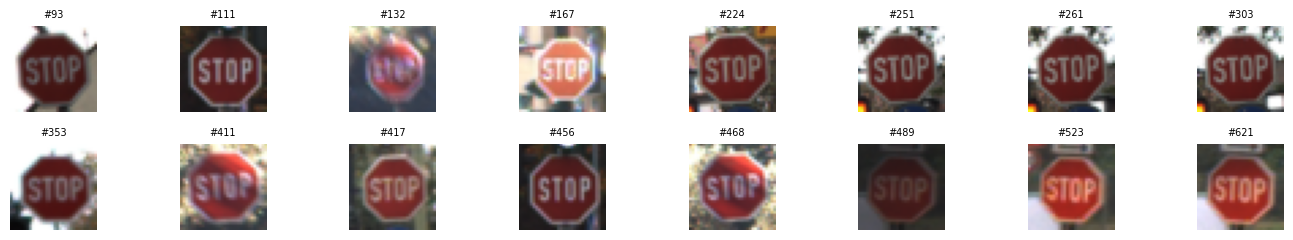

Showing 16 samples from class 14: 'Stop'


In [4]:
# Find the first correctly classified source image
MEAN = torch.tensor([0.3337, 0.3064, 0.3171]).view(3, 1, 1)
STD  = torch.tensor([0.2672, 0.2564, 0.2629]).view(3, 1, 1)

def denorm(t):
    """Undo normalization for display. t: (C,H,W) normalized tensor → [0,1]"""
    return (t * STD + MEAN).clamp(0, 1)

def show_images(imgs, titles=None, cols=8, figsize=(14, 3)):
    rows = max(1, len(imgs) // cols + int(len(imgs) % cols > 0))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < len(imgs):
            img = denorm(imgs[i]).permute(1, 2, 0).clamp(0, 1).numpy()
            ax.imshow(img)
            if titles: ax.set_title(titles[i], fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Pick 16 source class images to display
sample_idx = source_indices[:16]
sample_imgs = [dataset[i][0] for i in sample_idx]

show_images(
    sample_imgs,
    titles=[f"#{i}" for i in sample_idx],
    figsize=(14, 2.5)
)
print(f"Showing 16 samples from class {CFG['source_class']}: '{GTSRB_CLASSES[CFG['source_class']]}'")

In [5]:
from torchvision.models import resnet18
model = resnet18(num_classes=43)
model.load_state_dict(torch.load(CFG["model_path"], map_location=CFG["device"]))
# ─────────────────────────────────────────────────────────────────────────────

model = model.to(CFG["device"]).eval()
print("✓ Model loaded and set to eval mode")

# Quick sanity check: classify the source images
correct = 0
preds = []
with torch.no_grad():
    for img in sample_imgs:
        logits = model(img.unsqueeze(0).to(CFG["device"]))
        pred = logits.argmax(1).item()
        preds.append(pred)
        correct += int(pred == CFG["source_class"])

print(f"\nBaseline accuracy on {len(sample_imgs)} source images: {correct}/{len(sample_imgs)} ({100*correct/len(sample_imgs):.0f}%)")
print(f"Predictions: {preds}  (expected all {CFG['source_class']})")

✓ Model loaded and set to eval mode

Baseline accuracy on 16 source images: 16/16 (100%)
Predictions: [14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14]  (expected all 14)


✓ Selected image index 93
  Model prediction: 14 → 'Stop' ✓


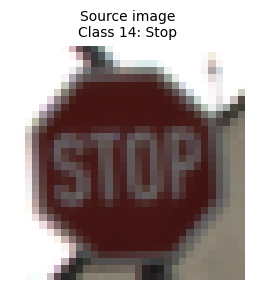


Image tensor shape: torch.Size([3, 32, 32])
Value range: [-0.938, 2.705]


In [6]:
x_orig = None
for idx in source_indices:
    img, label = dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(CFG["device"])).argmax(1).item()
    if pred == CFG["source_class"]:
        x_orig = img   # (C, H, W) in [0, 1]
        print(f"✓ Selected image index {idx}")
        print(f"  Model prediction: {pred} → '{GTSRB_CLASSES[pred]}' ✓")
        break

if x_orig is None:
    raise RuntimeError("No correctly classified source image found. Check your model.")

# Display it
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(denorm(x_orig).permute(1, 2, 0).numpy())
ax.set_title(f"Source image\nClass {CFG['source_class']}: {GTSRB_CLASSES[CFG['source_class']]}", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"\nImage tensor shape: {x_orig.shape}")
print(f"Value range: [{x_orig.min():.3f}, {x_orig.max():.3f}]")

Mask pixel region: rows 21–23, cols 9–25  (2×16 pixels = 32 px total, 3.1% of image)


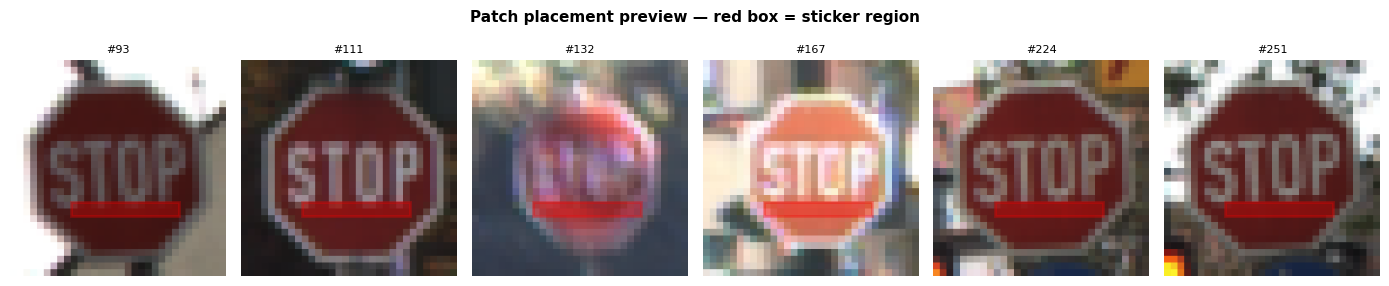


Happy with the placement? Adjust PATCH_CFG and re-run to fine-tune.
When satisfied, run the next cell to start training.


In [7]:
# ── Cell: Visualise patch placement before training ───────────────────────────

# Custom mask — small rectangle just below the STOP letters
# On a 32x32 image the sign face roughly occupies the center
# "Just below STOP text" ≈ vertical range 55-70%, horizontal range 20-80%

def build_custom_mask(image_size=32, row_start=0.65, row_end=0.70,
                                     col_start=0.20, col_end=0.80):
    """
    Build mask using fractional coordinates so it's easy to
    visually tune — just adjust the fractions and re-run.
    
    row_start/end : vertical position (0=top, 1=bottom)
    col_start/end : horizontal position (0=left, 1=right)
    """
    H = W = image_size
    mask = torch.zeros(1, H, W)
    r0 = int(H * row_start);  r1 = int(H * row_end)
    c0 = int(W * col_start);  c1 = int(W * col_end)
    mask[:, r0:r1, c0:c1] = 1.0
    print(f"Mask pixel region: rows {r0}–{r1}, cols {c0}–{c1}  "
          f"({r1-r0}×{c1-c0} pixels = {(r1-r0)*(c1-c0)} px total, "
          f"{mask.mean()*100:.1f}% of image)")
    return mask, (r0, r1, c0, c1)


# ── Tune these four numbers to move/resize the patch ─────────────────────────
PATCH_CFG = dict(
    row_start = 0.68,   # ↕ top edge of patch
    row_end   = 0.73,   # ↕ bottom edge of patch
    col_start = 0.30,   # ↔ left edge of patch
    col_end   = 0.80,   # ↔ right edge of patch
)

mask_custom, (r0, r1, c0, c1) = build_custom_mask(CFG["image_size"], **PATCH_CFG)

# ── Visualise on several stop sign images ─────────────────────────────────────
import matplotlib.patches as mpatches

n_show = 6
fig, axes = plt.subplots(1, n_show, figsize=(14, 3))
fig.suptitle("Patch placement preview — red box = sticker region", 
             fontsize=11, fontweight="bold")

for ax, idx in zip(axes, source_indices[:n_show]):
    img, _ = dataset[idx]
    img_disp = denorm(img).permute(1, 2, 0).numpy()
    
    # Upscale for visibility (32x32 is tiny)
    scale = 6
    img_up = np.repeat(np.repeat(img_disp, scale, axis=0), scale, axis=1)
    ax.imshow(img_up)
    
    # Draw patch rectangle (scaled)
    rect = mpatches.Rectangle(
        (c0 * scale, r0 * scale),          # (x, y) = (col, row)
        (c1 - c0) * scale,                 # width
        (r1 - r0) * scale,                 # height
        linewidth=2, edgecolor="red",
        facecolor="red", alpha=0.3
    )
    ax.add_patch(rect)
    ax.set_title(f"#{idx}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\nHappy with the placement? Adjust PATCH_CFG and re-run to fine-tune.")
print("When satisfied, run the next cell to start training.")

In [8]:
import torch.nn.functional as F

class PhysicalTransformSampler:
    """
    All ops are pure PyTorch — autograd graph stays intact so
    gradients flow all the way back to delta.
    """
    def __init__(
        self,
        angle_range      = (-15, 15),
        scale_range      = (0.8, 1.2),
        brightness_range = (0.7, 1.3),
        contrast_range   = (0.8, 1.2),
        noise_std        = 0.02,
    ):
        self.angle_range      = angle_range
        self.scale_range      = scale_range
        self.brightness_range = brightness_range
        self.contrast_range   = contrast_range
        self.noise_std        = noise_std

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        """x: (C,H,W) normalised tensor — returns transformed (C,H,W), graph intact."""

        x = x.unsqueeze(0)   # (1,C,H,W) for grid_sample

        # 1. Rotation + scale via affine grid (fully differentiable)
        angle = np.random.uniform(*self.angle_range)
        scale = np.random.uniform(*self.scale_range)
        rad   = torch.tensor(angle * np.pi / 180.0, dtype=torch.float32)
        cos_a, sin_a = torch.cos(rad), torch.sin(rad)

        # 2×3 affine matrix: rotation + scale combined
        theta = torch.tensor([[
            [cos_a / scale, -sin_a / scale, 0.0],
            [sin_a / scale,  cos_a / scale, 0.0],
        ]], dtype=torch.float32, device=x.device)

        grid = F.affine_grid(theta, x.shape, align_corners=False)
        x    = F.grid_sample(x, grid, align_corners=False, padding_mode="border")

        x = x.squeeze(0)   # back to (C,H,W)

        # 2. Brightness (multiplicative — differentiable)
        brightness = np.random.uniform(*self.brightness_range)
        x = x * brightness

        # 3. Contrast (differentiable)
        contrast = np.random.uniform(*self.contrast_range)
        mean = x.mean(dim=(1, 2), keepdim=True)
        x    = (x - mean) * contrast + mean

        # 4. Gaussian noise (differentiable — adds to graph but gradient passes through)
        x = x + torch.randn_like(x) * self.noise_std

        return x   # stays normalised — no re-normalize needed

sampler = PhysicalTransformSampler()

In [13]:
MEAN = torch.tensor([0.3337, 0.3064, 0.3171]).view(3,1,1).to(CFG["device"])
STD  = torch.tensor([0.2672, 0.2564, 0.2629]).view(3,1,1).to(CFG["device"])

mask=mask_custom.cuda()
x = x_orig.to(CFG["device"])
target = torch.tensor([CFG["target_class"]], device=CFG["device"])

# δ lives in NORMALISED space — same space as x
delta = (torch.rand_like(x) * 2 - 1) * 0.01 * mask
delta = delta.detach().requires_grad_(True)

optimizer = torch.optim.SGD([delta], lr=CFG["alpha"],momentum=0.99)
criterion = nn.CrossEntropyLoss()

# ── Helpers ───────────────────────────────────────────────────────────────────

def apply_perturbation(x, delta):
    # NO clamp here — x is normalised, values live in ~[-1, 3]
    # Clamping to [0,1] would destroy most of the image
    return x + mask * delta

def tv_loss(delta):
    # delta is (C, H, W) — index along H and W dims
    diff_h = (delta[:, 1:, :] - delta[:, :-1, :]).abs().mean()
    diff_w = (delta[:, :, 1:] - delta[:, :, :-1]).abs().mean()
    return diff_h + diff_w

def project(delta):
    # Only constrain delta itself — NOT the full image
    return delta.clamp(-CFG["epsilon"], CFG["epsilon"]) * mask

print("✓ Cell 8 ready")
print(f"  x range     : [{x.min():.3f}, {x.max():.3f}]  (normalised — expected ~[-1, 3])")
print(f"  delta range : [{delta.min():.4f}, {delta.max():.4f}]  (tiny init noise)")
print(f"  ε budget    : ±{CFG['epsilon']}")

✓ Cell 8 ready
  x range     : [-0.938, 2.705]  (normalised — expected ~[-1, 3])
  delta range : [-0.0099, 0.0098]  (tiny init noise)
  ε budget    : ±0.7


In [17]:
all_source_imgs = []
for idx in source_indices:
    img, _ = dataset[idx]
    all_source_imgs.append(img.to(CFG["device"]))

In [12]:
# ── Paper-faithful RP2 — no L∞ constraint, graffiti-style visible patch ───────



print(f"Training with:")
print(f"  Mask     : custom rectangle (just below STOP text)")
print(f"  Epsilon  : NO hard constraint — paper-faithful")
print(f"  Budget   : controlled only by L2 regulariser (lambda_lp)")
print(f"  Images   : {len(all_source_imgs)} stop signs (full batch)\n")

# Use the custom mask from the visualisation cell
mask = mask_custom.to(CFG["device"])

# Reinitialise delta — no epsilon constraint so init with slightly larger noise
delta_paper = (torch.rand_like(all_source_imgs[0]) * 2 - 1) * 0.05 * mask
delta_paper = delta_paper.detach().requires_grad_(True)

optimizer_paper = torch.optim.Adam([delta_paper], lr=CFG["alpha"])

# Paper-faithful helpers — no L∞ projection
def apply_perturbation_paper(x, delta):
    return x + mask * delta          # no clamp — free to shift colours widely

def project_paper(delta):
    return delta * mask              # only enforce mask boundary, no ε ball

# Increase L2 reg slightly to compensate for removed L∞ constraint
lambda_lp = 0.005   # stronger than before to keep patch printable
lambda_tv = 1e-4    # smoothness — makes it look like a coherent sticker

loss_history_paper = []

print(f"{'Step':>6}  {'Total Loss':>11}  {'CE Loss':>9}  {'L2 norm':>9}  {'ASR':>6}")
print("-" * 55)

for step in range(CFG["num_steps"]):
    optimizer_paper.zero_grad()

    total_cls_loss = torch.tensor(0.0, device=CFG["device"])
    n_samples = 0

    # Full batch: every image × every transform
    for x_i in all_source_imgs:
        for _ in range(CFG["num_transforms"]):
            x_adv         = apply_perturbation_paper(x_i, delta_paper)
            x_t           = sampler(x_adv)
            total_cls_loss += criterion(model(x_t.unsqueeze(0)), target)
            n_samples     += 1

    cls_loss  = total_cls_loss / n_samples
    loss_tv   = tv_loss(mask * delta_paper)
    loss_lp   = (mask * delta_paper).norm(p=2)
    loss      = cls_loss + lambda_tv * loss_tv + lambda_lp * loss_lp

    loss.backward()
    optimizer_paper.step()

    # Paper-faithful projection — mask only, no ε clamp
    with torch.no_grad():
        delta_paper.data = project_paper(delta_paper.data)

    loss_history_paper.append(loss.item())

    if (step + 1) % 20 == 0 or step == 0:
        with torch.no_grad():
            hits = sum(
                int(model(apply_perturbation_paper(x_i, delta_paper).unsqueeze(0)
                    ).argmax(1).item() == CFG["target_class"])
                for x_i in all_source_imgs
            )
        asr  = hits / len(all_source_imgs)
        l2   = (mask * delta_paper).norm(p=2).item()
        print(f"{step+1:>6}  {loss.item():>11.4f}  {cls_loss.item():>9.4f}  "
              f"{l2:>9.3f}  {asr:>5.0%}  {'✓' if asr > 0.9 else ''}")

print("\n✓ Training complete!")

Training with:
  Mask     : custom rectangle (just below STOP text)
  Epsilon  : NO hard constraint — paper-faithful
  Budget   : controlled only by L2 regulariser (lambda_lp)
  Images   : 270 stop signs (full batch)

  Step   Total Loss    CE Loss    L2 norm     ASR
-------------------------------------------------------
     1       8.3635     8.3621      0.303     6%  
    20       7.4408     7.4321      1.828     9%  
    40       6.3650     6.3476      3.542    15%  
    60       5.3002     5.2746      5.199    19%  
    80       4.5966     4.5635      6.682    25%  
   100       4.1339     4.0951      7.807    34%  
   120       3.7717     3.7285      8.668    41%  
   140       3.4894     3.4428      9.354    41%  
   160       3.3641     3.3146      9.916    40%  
   180       3.3494     3.2974     10.407    40%  
   200       3.1910     3.1368     10.868    41%  
   220       3.2002     3.1437     11.311    41%  
   240       3.0974     3.0388     11.734    43%  
   260       

KeyboardInterrupt: 

In [14]:
# ── Quick mask size comparison — 100 steps each ───────────────────────────────
MAX_L2 = 8.0   # define it here

def project_l2(delta, mask, max_l2=MAX_L2):
    """Project delta onto L2 ball and zero outside mask."""
    d = delta * mask
    current_norm = d.norm(p=2)
    if current_norm > max_l2:
        d = d * (max_l2 / current_norm)
    return d   # mask already applied

for label, patch_cfg in [
    ("small  ", dict(row_start=0.52, row_end=0.72, col_start=0.15, col_end=0.85)),
    ("medium ", dict(row_start=0.45, row_end=0.75, col_start=0.15, col_end=0.85)),
    ("large  ", dict(row_start=0.40, row_end=0.80, col_start=0.10, col_end=0.90)),
]:
    m, _ = build_custom_mask(CFG["image_size"], **patch_cfg)
    m    = m.to(CFG["device"])
    d    = (torch.rand_like(all_source_imgs[0]) * 2 - 1) * 0.05 * m
    d    = d.detach().requires_grad_(True)
    opt  = torch.optim.Adam([d], lr=0.01)

    for step in range(100):
        opt.zero_grad()
        loss = torch.tensor(0.0, device=CFG["device"])
        for x_i in all_source_imgs:
            x_t   = sampler(x_i + m * d)
            loss += criterion(model(x_t.unsqueeze(0)), target)
        loss = loss / len(all_source_imgs)
        loss += 0.05  * (m * d).norm(p=2)
        loss += 1e-4  * tv_loss(m * d)
        loss.backward()
        opt.step()

        # ── Project after every step ──────────────────────────────────
        with torch.no_grad():
            d.data = project_l2(d.data, m)

    with torch.no_grad():
        hits = sum(
            int(model((x_i + m * d).unsqueeze(0)).argmax(1).item() == CFG["target_class"])
            for x_i in all_source_imgs
        )
    coverage = m.mean() * 100
    print(f"{label} | coverage={coverage:.0f}% | L2={d.norm(p=2):.2f} | ASR@100steps={hits/len(all_source_imgs):.0%}")

Mask pixel region: rows 16–23, cols 4–27  (7×23 pixels = 161 px total, 15.7% of image)
small   | coverage=16% | L2=8.00 | ASR@100steps=79%
Mask pixel region: rows 14–24, cols 4–27  (10×23 pixels = 230 px total, 22.5% of image)
medium  | coverage=22% | L2=8.00 | ASR@100steps=88%
Mask pixel region: rows 12–25, cols 3–28  (13×25 pixels = 325 px total, 31.7% of image)
large   | coverage=32% | L2=8.00 | ASR@100steps=93%


In [14]:
# ── Final Paper-faithful Universal Patch — Medium mask, 500 steps ─────────────

# Build medium mask
mask_final, (r0, r1, c0, c1) = build_custom_mask(
    CFG["image_size"],
    row_start=0.45, row_end=0.75,
    col_start=0.15, col_end=0.85
)
mask_final = mask_final.to(CFG["device"])

MAX_L2     = 8.0
lambda_lp  = 0.05
lambda_tv  = 1e-4
num_steps  = 500

def project_l2(delta, mask, max_l2=MAX_L2):
    d = delta * mask
    current_norm = d.norm(p=2)
    if current_norm > max_l2:
        d = d * (max_l2 / current_norm)
    return d

Mask pixel region: rows 14–24, cols 4–27  (10×23 pixels = 230 px total, 22.5% of image)


In [15]:


# Fresh delta
delta_final = (torch.rand_like(all_source_imgs[0]) * 2 - 1) * 0.05 * mask_final
delta_final = delta_final.detach().requires_grad_(True)
optimizer_final = torch.optim.Adam([delta_final], lr=0.01)

loss_history_final = []

print(f"Training universal patch — medium mask ({mask_final.mean()*100:.0f}% coverage), {num_steps} steps")
print(f"Samples per step: {len(all_source_imgs)} images × {CFG['num_transforms']} transforms = {len(all_source_imgs)*CFG['num_transforms']}\n")
print(f"{'Step':>6}  {'Total Loss':>11}  {'CE Loss':>9}  {'L2 norm':>9}  {'ASR':>6}")
print("-" * 55)

for step in range(num_steps):
    optimizer_final.zero_grad()

    total_cls_loss = torch.tensor(0.0, device=CFG["device"])
    n_samples = 0

    for x_i in all_source_imgs:
        for _ in range(CFG["num_transforms"]):
            x_adv          = x_i + mask_final * delta_final
            x_t            = sampler(x_adv)
            total_cls_loss += criterion(model(x_t.unsqueeze(0)), target)
            n_samples      += 1

    cls_loss = total_cls_loss / n_samples
    loss_tv  = tv_loss(mask_final * delta_final)
    loss_lp  = (mask_final * delta_final).norm(p=2)
    loss     = cls_loss + lambda_tv * loss_tv + lambda_lp * loss_lp

    loss.backward()
    optimizer_final.step()

    with torch.no_grad():
        delta_final.data = project_l2(delta_final.data, mask_final)

    loss_history_final.append(loss.item())

    if (step + 1) % 50 == 0 or step == 0:
        with torch.no_grad():
            hits = sum(
                int(model((x_i + mask_final * delta_final).unsqueeze(0)
                    ).argmax(1).item() == CFG["target_class"])
                for x_i in all_source_imgs
            )
        asr = hits / len(all_source_imgs)
        l2  = (mask_final * delta_final).norm(p=2).item()
        print(f"{step+1:>6}  {loss.item():>11.4f}  {cls_loss.item():>9.4f}  "
              f"{l2:>9.3f}  {asr:>5.0%}  {'✓' if asr >= 0.9 else ''}")

print("\n✓ Training complete!")

# ── Final evaluation ──────────────────────────────────────────────────────────
print("\n--- Final Evaluation ---")
with torch.no_grad():
    clean_hits = sum(
        int(model((x_i + mask_final * delta_final).unsqueeze(0)
            ).argmax(1).item() == CFG["target_class"])
        for x_i in all_source_imgs
    )

robust_hits, robust_total = 0, 0
with torch.no_grad():
    for x_i in all_source_imgs:
        for _ in range(10):
            x_t = sampler(x_i + mask_final * delta_final)
            robust_hits  += int(model(x_t.unsqueeze(0)).argmax(1).item() == CFG["target_class"])
            robust_total += 1

clean_asr  = clean_hits / len(all_source_imgs)
robust_asr = robust_hits / robust_total
print(f"  Clean ASR  (no transform) : {clean_hits}/{len(all_source_imgs)} = {clean_asr:.0%}")
print(f"  Robust ASR (w/ transforms): {robust_hits}/{robust_total} = {robust_asr:.0%}")
print(f"  Patch L2 norm             : {(mask_final * delta_final).norm(p=2).item():.3f}")
print(f"  Patch max pixel shift     : {(mask_final * delta_final).abs().max().item():.3f}")

# ── Visualise patch on 6 images ───────────────────────────────────────────────
scale = 6
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle(f"Universal patch — medium mask | clean ASR={clean_asr:.0%} | robust ASR={robust_asr:.0%}",
             fontsize=10, fontweight="bold")

for col, idx in enumerate(source_indices[:6]):
    img, _ = dataset[idx]
    img    = img.to(CFG["device"])

    # Row 0: original
    axes[0, col].imshow(np.repeat(np.repeat(
        denorm(img).permute(1,2,0).cpu().numpy(), scale, 0), scale, 1))
    axes[0, col].set_title(f"Original #{idx}", fontsize=7)
    axes[0, col].axis("off")

    # Row 1: adversarial
    x_adv = (img + mask_final * delta_final).cpu()
    pred  = model((img + mask_final * delta_final).unsqueeze(0)).argmax(1).item()
    axes[1, col].imshow(np.repeat(np.repeat(
        denorm(x_adv).permute(1,2,0).numpy(), scale, 0), scale, 1))
    axes[1, col].set_title(
        f"Pred: {pred} {'✓' if pred==CFG['target_class'] else '✗'}",
        fontsize=7, color="green" if pred==CFG["target_class"] else "red"
    )
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs("./patches", exist_ok=True)
torch.save({
    "delta"       : delta_final.detach().cpu(),
    "mask"        : mask_final.cpu(),
    "patch_cfg"   : dict(row_start=0.45, row_end=0.75, col_start=0.15, col_end=0.85),
    "source_class": CFG["source_class"],
    "target_class": CFG["target_class"],
    "image_size"  : CFG["image_size"],
    "MAX_L2"      : MAX_L2,
    "lambda_lp"   : lambda_lp,
    "lambda_tv"   : lambda_tv,
    "num_steps"   : num_steps,
    "clean_asr"   : clean_asr,
    "robust_asr"  : robust_asr,
}, f"./patches/rp2_universal_medium_src{CFG['source_class']}_tgt{CFG['target_class']}.pt")
print(f"\n✓ Patch saved → ./patches/rp2_universal_medium_src{CFG['source_class']}_tgt{CFG['target_class']}.pt")

Mask pixel region: rows 14–24, cols 4–27  (10×23 pixels = 230 px total, 22.5% of image)
Training universal patch — medium mask (22% coverage), 500 steps
Samples per step: 270 images × 10 transforms = 2700

  Step   Total Loss    CE Loss    L2 norm     ASR
-------------------------------------------------------
     1       8.2608     8.2227      0.817     9%  
    50       1.3338     0.9543      7.675    82%  
   100       0.9830     0.5830      8.000    86%  


KeyboardInterrupt: 

NameError: name 'delta_final' is not defined

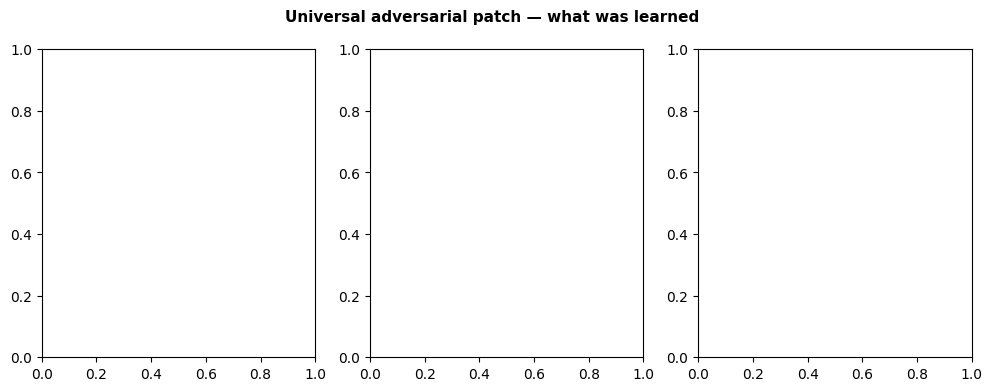

In [18]:
# ── Visualise the universal patch attack ─────────────────────────────────────

MEAN = torch.tensor([0.3337, 0.3064, 0.3171]).view(3,1,1)
STD  = torch.tensor([0.2672, 0.2564, 0.2629]).view(3,1,1)

def denorm(t):
    return (t.cpu() * STD + MEAN).clamp(0, 1)

scale = 6   # upscale factor for visibility (32×32 → 192×192)

# ── Panel 1: The patch itself ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Universal adversarial patch — what was learned", fontsize=11, fontweight="bold")

# Raw delta (amplified for visibility)
patch_vis = denorm(mask_final.cpu() * delta_final.detach().cpu() * 3 + 0.5).squeeze()
axes[0].imshow(np.repeat(np.repeat(patch_vis.permute(1,2,0).numpy(), scale, 0), scale, 1))
axes[0].set_title("Learned patch δ\n(amplified ×3)", fontsize=9)
axes[0].axis("off")

# Mask shape
axes[1].imshow(np.repeat(np.repeat(
    mask_final.cpu().squeeze(0).numpy(), scale, 0), scale, 1), cmap="gray")
axes[1].set_title(f"Mask region\n(22% coverage)", fontsize=9)
axes[1].axis("off")

# Patch pixel value distribution
delta_vals = (mask_final.cpu() * delta_final.detach().cpu())
delta_vals = delta_vals[delta_vals != 0].numpy().flatten()
axes[2].hist(delta_vals, bins=40, color="steelblue", alpha=0.8, edgecolor="white")
axes[2].axvline(0, color="red", ls="--", lw=1.5, label="zero (no change)")
axes[2].set_title("Patch value distribution\n(how much each pixel shifted)", fontsize=9)
axes[2].set_xlabel("δ value"); axes[2].set_ylabel("count")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Panel 2: Original vs adversarial on 8 images ─────────────────────────────
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
fig.suptitle("Original (top) vs adversarial with universal patch (bottom)",
             fontsize=11, fontweight="bold")

with torch.no_grad():
    for col, idx in enumerate(source_indices[:n_show]):
        img, _ = dataset[idx]
        img    = img.to(CFG["device"])

        # Original
        orig_disp = np.repeat(np.repeat(
            denorm(img).permute(1,2,0).numpy(), scale, 0), scale, 1)
        axes[0, col].imshow(orig_disp)
        axes[0, col].set_title(f"Stop sign\n#{idx}", fontsize=7)
        axes[0, col].axis("off")

        # Adversarial
        x_adv = img + mask_final * delta_final
        adv_disp = np.repeat(np.repeat(
            denorm(x_adv).permute(1,2,0).numpy(), scale, 0), scale, 1)
        pred  = model(x_adv.unsqueeze(0)).argmax(1).item()
        conf  = torch.softmax(model(x_adv.unsqueeze(0)), dim=1)[0][CFG["target_class"]].item()
        axes[1, col].imshow(adv_disp)
        axes[1, col].set_title(
            f"{GTSRB_CLASSES[pred][:15]}\nconf={conf:.0%} {'✓' if pred==CFG['target_class'] else '✗'}",
            fontsize=7,
            color="green" if pred == CFG["target_class"] else "red"
        )
        axes[1, col].axis("off")

plt.tight_layout()
plt.show()

# ── Panel 3: Robustness — show patch surviving transforms ────────────────────
n_imgs    = 3
n_samples = 5
fig, axes = plt.subplots(n_imgs, n_samples + 1, figsize=(14, 7))
fig.suptitle("Patch robustness — adversarial image under random physical transforms",
             fontsize=11, fontweight="bold")

with torch.no_grad():
    for row, idx in enumerate(source_indices[:n_imgs]):
        img, _ = dataset[idx]
        img    = img.to(CFG["device"])
        x_adv  = img + mask_final * delta_final

        # First col: clean adversarial
        axes[row, 0].imshow(np.repeat(np.repeat(
            denorm(x_adv).permute(1,2,0).numpy(), scale, 0), scale, 1))
        axes[row, 0].set_title("Patched\n(no transform)", fontsize=7, fontweight="bold")
        axes[row, 0].axis("off")

        # Remaining cols: random transforms
        for t in range(n_samples):
            x_t  = sampler(x_adv)
            pred = model(x_t.unsqueeze(0)).argmax(1).item()
            conf = torch.softmax(model(x_t.unsqueeze(0)), dim=1)[0][CFG["target_class"]].item()
            axes[row, t+1].imshow(np.repeat(np.repeat(
                denorm(x_t).permute(1,2,0).numpy(), scale, 0), scale, 1))
            axes[row, t+1].set_title(
                f"T{t+1}: pred={pred}\n{'✓' if pred==CFG['target_class'] else '✗'} {conf:.0%}",
                fontsize=7,
                color="green" if pred==CFG["target_class"] else "red"
            )
            axes[row, t+1].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# ── Small mask — how far can we push it? ─────────────────────────────────────

mask_small, (r0, r1, c0, c1) = build_custom_mask(
    CFG["image_size"],
    row_start=0.52, row_end=0.72,
    col_start=0.15, col_end=0.85
)
mask_small = mask_small.to(CFG["device"])
print(f"Small mask: {mask_small.mean()*100:.1f}% coverage")

# ── Experiment: try different MAX_L2 budgets to see the ceiling ───────────────
# Since the mask is small, the only lever we have is how large
# we allow the patch values to grow — let's sweep it

results = {}

for max_l2 in [8.0, 12.0, 16.0]:
    d    = (torch.rand_like(all_source_imgs[0]) * 2 - 1) * 0.05 * mask_small
    d    = d.detach().requires_grad_(True)
    opt  = torch.optim.Adam([d], lr=0.01)

    for step in range(500):
        opt.zero_grad()
        total_loss = torch.tensor(0.0, device=CFG["device"])
        n = 0
        for x_i in all_source_imgs:
            for _ in range(CFG["num_transforms"]):
                x_t = sampler(x_i + mask_small * d)
                total_loss += criterion(model(x_t.unsqueeze(0)), target)
                n += 1
        loss  = total_loss / n
        loss += lambda_tv * tv_loss(mask_small * d)
        loss += lambda_lp * (mask_small * d).norm(p=2)
        loss.backward()
        opt.step()
        with torch.no_grad():
            d.data = project_l2(d.data, mask_small, max_l2=max_l2)

    with torch.no_grad():
        clean_hits = sum(
            int(model((x_i + mask_small * d).unsqueeze(0)
                ).argmax(1).item() == CFG["target_class"])
            for x_i in all_source_imgs
        )
        robust_hits, robust_total = 0, 0
        for x_i in all_source_imgs:
            for _ in range(10):
                x_t = sampler(x_i + mask_small * d)
                robust_hits  += int(model(x_t.unsqueeze(0)).argmax(1).item() == CFG["target_class"])
                robust_total += 1

    clean_asr  = clean_hits / len(all_source_imgs)
    robust_asr = robust_hits / robust_total
    results[max_l2] = dict(d=d.detach().clone(), clean=clean_asr, robust=robust_asr)

    print(f"MAX_L2={max_l2:5.1f} | clean ASR={clean_asr:.0%} | robust ASR={robust_asr:.0%} | "
          f"actual L2={( mask_small * d).norm(p=2).item():.2f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'MAX_L2':>8}  {'Clean ASR':>10}  {'Robust ASR':>11}  {'Tradeoff':>20}")
print("-" * 58)
for max_l2, r in results.items():
    tradeoff = "more visible" if max_l2 > 8 else "realistic sticker"
    print(f"{max_l2:>8.1f}  {r['clean']:>10.0%}  {r['robust']:>11.0%}  {tradeoff:>20}")

# ── Visualise all three patches side by side ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Small mask — patch appearance at different L2 budgets",
             fontsize=11, fontweight="bold")

for ax, (max_l2, r) in zip(axes, results.items()):
    patch_vis = denorm(mask_small.cpu() * r["d"].cpu() * 3 + 0.5)
    ax.imshow(np.repeat(np.repeat(
        patch_vis.squeeze().permute(1,2,0).numpy(), 6, 0), 6, 1))
    ax.set_title(f"MAX_L2={max_l2}\nclean={r['clean']:.0%} robust={r['robust']:.0%}",
                 fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Save the best one (highest robust ASR)
best_l2 = max(results, key=lambda k: results[k]["robust"])
torch.save({
    "delta"       : results[best_l2]["d"].cpu(),
    "mask"        : mask_small.cpu(),
    "MAX_L2"      : best_l2,
    "clean_asr"   : results[best_l2]["clean"],
    "robust_asr"  : results[best_l2]["robust"],
    "source_class": CFG["source_class"],
    "target_class": CFG["target_class"],
}, f"./patches/rp2_universal_small_best.pt")
print(f"\n✓ Best small patch saved (MAX_L2={best_l2}, robust ASR={results[best_l2]['robust']:.0%})")

Mask pixel region: rows 16–23, cols 4–27  (7×23 pixels = 161 px total, 15.7% of image)
Small mask: 15.7% coverage


KeyboardInterrupt: 

In [21]:
mask_small, (r0, r1, c0, c1) = build_custom_mask(
    CFG["image_size"],
    row_start=0.52, row_end=0.72,
    col_start=0.15, col_end=0.85
)
mask_small = mask_small.to(CFG["device"])

delta_small = (torch.rand_like(all_source_imgs[0]) * 2 - 1) * 0.05 * mask_small

delta_small = delta_small.detach().requires_grad_(True)
optimizer_small = torch.optim.Adam([delta_small], lr=0.01)

Mask pixel region: rows 16–23, cols 4–27  (7×23 pixels = 161 px total, 15.7% of image)


In [18]:
# ── Single run — small mask, MAX_L2=8.0, 500 steps ───────────────────────────



MAX_L2 = 8.0

print(f"Small mask: {mask_small.mean()*100:.1f}% coverage | MAX_L2={MAX_L2} | 500 steps\n")
print(f"{'Step':>6}  {'CE Loss':>9}  {'L2 norm':>9}  {'ASR':>6}")
print("-" * 40)

for step in range(500):
    optimizer_small.zero_grad()
    total_loss = torch.tensor(0.0, device=CFG["device"])
    n = 0
    for x_i in all_source_imgs:
        for _ in range(CFG["num_transforms"]):
            x_t = sampler(x_i + mask_small * delta_small)
            total_loss += criterion(model(x_t.unsqueeze(0)), target)
            n += 1
    loss  = total_loss / n
    loss += lambda_tv * tv_loss(mask_small * delta_small)
    loss += lambda_lp * (mask_small * delta_small).norm(p=2)
    loss.backward()
    optimizer_small.step()
    with torch.no_grad():
        delta_small.data = project_l2(delta_small.data, mask_small, max_l2=MAX_L2)

    if (step + 1) % 50 == 0 or step == 0:
        with torch.no_grad():
            hits = sum(
                int(model((x_i + mask_small * delta_small).unsqueeze(0)
                    ).argmax(1).item() == CFG["target_class"])
                for x_i in all_source_imgs
            )
        asr = hits / len(all_source_imgs)
        l2  = (mask_small * delta_small).norm(p=2).item()
        print(f"{step+1:>6}  {loss.item():>9.4f}  {l2:>9.3f}  {asr:>5.0%}")

print("\n✓ Done!")

Mask pixel region: rows 16–23, cols 4–27  (7×23 pixels = 161 px total, 15.7% of image)
Small mask: 15.7% coverage | MAX_L2=8.0 | 500 steps

  Step    CE Loss    L2 norm     ASR
----------------------------------------
     1     8.4944      0.656     8%
    50     2.1453      6.956    67%
   100     1.5432      8.000    79%
   150     1.4239      8.000    80%


KeyboardInterrupt: 

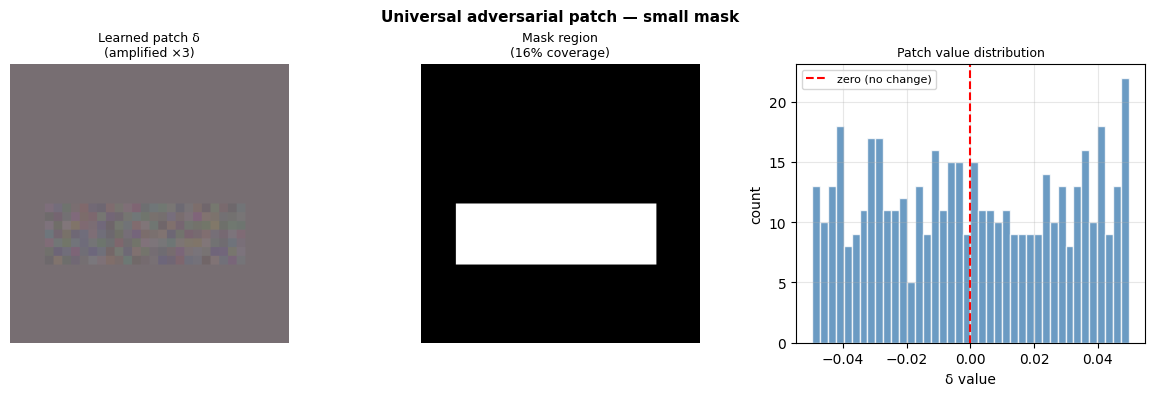

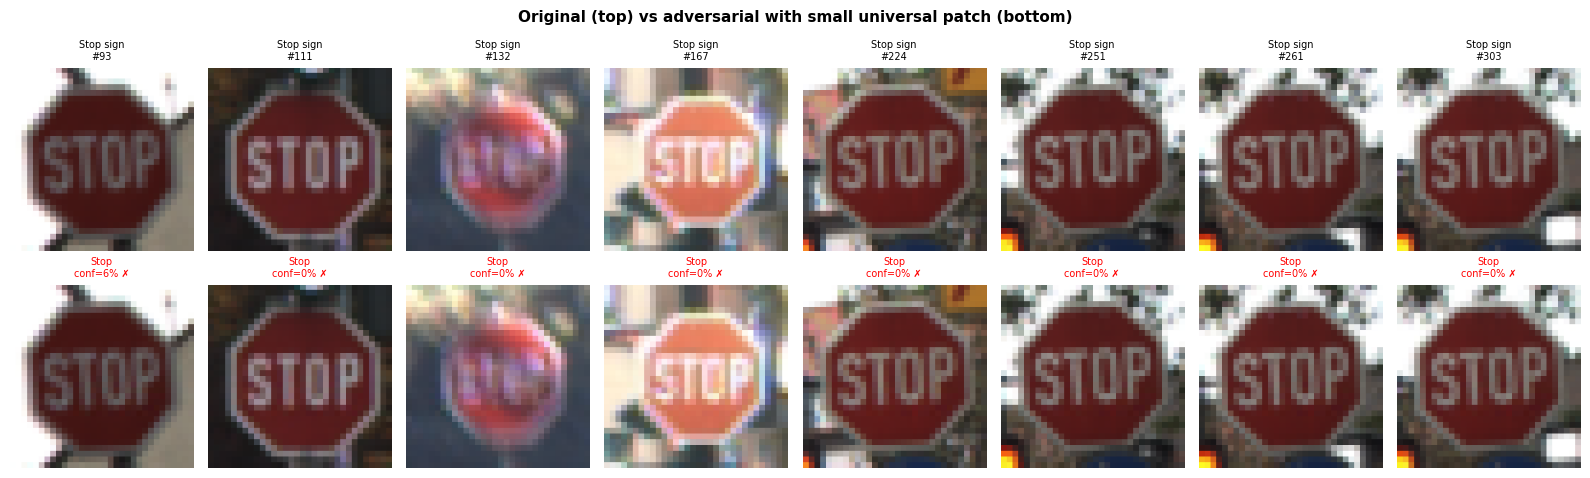

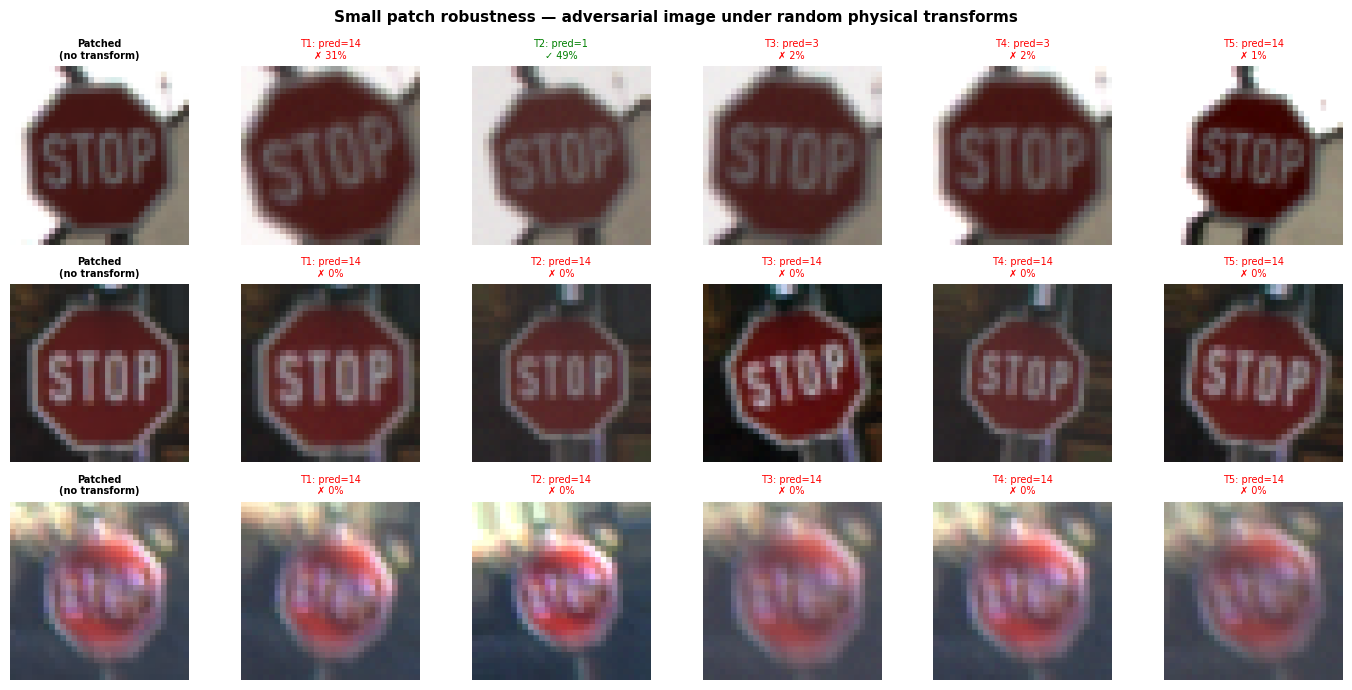

NameError: name 'delta_final' is not defined

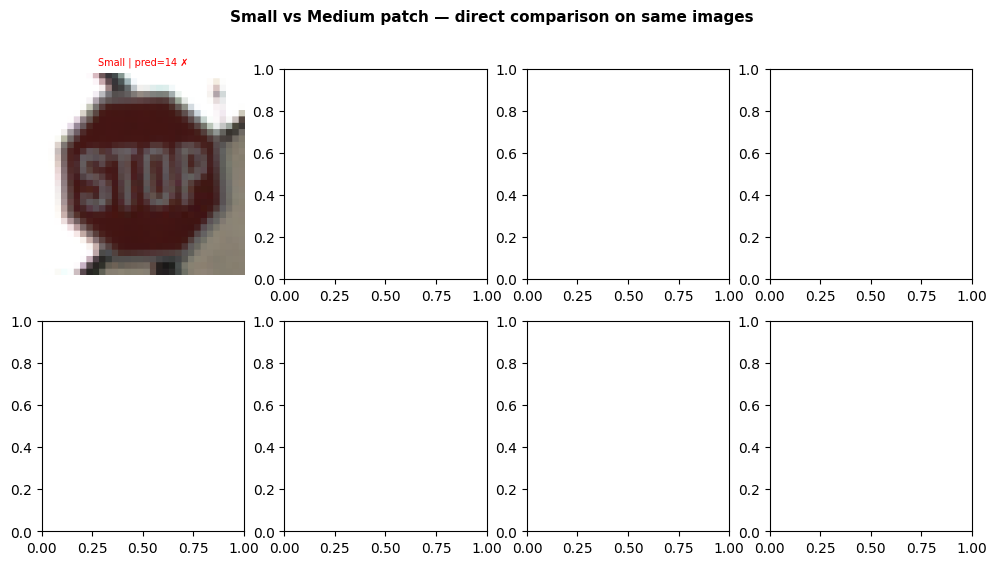

In [22]:
# ── Visualise small patch attack ──────────────────────────────────────────────

scale = 6

# ── Panel 1: The patch itself ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Universal adversarial patch — small mask", fontsize=11, fontweight="bold")

patch_vis = denorm(mask_small.cpu() * delta_small.detach().cpu() * 3 + 0.5).squeeze()
axes[0].imshow(np.repeat(np.repeat(patch_vis.permute(1,2,0).numpy(), scale, 0), scale, 1))
axes[0].set_title("Learned patch δ\n(amplified ×3)", fontsize=9)
axes[0].axis("off")

axes[1].imshow(np.repeat(np.repeat(
    mask_small.cpu().squeeze(0).numpy(), scale, 0), scale, 1), cmap="gray")
axes[1].set_title(f"Mask region\n(16% coverage)", fontsize=9)
axes[1].axis("off")

delta_vals = (mask_small.cpu() * delta_small.detach().cpu())
delta_vals = delta_vals[delta_vals != 0].numpy().flatten()
axes[2].hist(delta_vals, bins=40, color="steelblue", alpha=0.8, edgecolor="white")
axes[2].axvline(0, color="red", ls="--", lw=1.5, label="zero (no change)")
axes[2].set_title("Patch value distribution", fontsize=9)
axes[2].set_xlabel("δ value"); axes[2].set_ylabel("count")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Panel 2: Original vs adversarial on 8 images ─────────────────────────────
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
fig.suptitle("Original (top) vs adversarial with small universal patch (bottom)",
             fontsize=11, fontweight="bold")

with torch.no_grad():
    for col, idx in enumerate(source_indices[:n_show]):
        img, _ = dataset[idx]
        img    = img.to(CFG["device"])

        axes[0, col].imshow(np.repeat(np.repeat(
            denorm(img).permute(1,2,0).numpy(), scale, 0), scale, 1))
        axes[0, col].set_title(f"Stop sign\n#{idx}", fontsize=7)
        axes[0, col].axis("off")

        x_adv = img + mask_small * delta_small
        pred  = model(x_adv.unsqueeze(0)).argmax(1).item()
        conf  = torch.softmax(model(x_adv.unsqueeze(0)), dim=1)[0][CFG["target_class"]].item()
        axes[1, col].imshow(np.repeat(np.repeat(
            denorm(x_adv).permute(1,2,0).numpy(), scale, 0), scale, 1))
        axes[1, col].set_title(
            f"{GTSRB_CLASSES[pred][:15]}\nconf={conf:.0%} {'✓' if pred==CFG['target_class'] else '✗'}",
            fontsize=7,
            color="green" if pred==CFG["target_class"] else "red"
        )
        axes[1, col].axis("off")

plt.tight_layout()
plt.show()

# ── Panel 3: Robustness under transforms ─────────────────────────────────────
n_imgs, n_samples = 3, 5
fig, axes = plt.subplots(n_imgs, n_samples + 1, figsize=(14, 7))
fig.suptitle("Small patch robustness — adversarial image under random physical transforms",
             fontsize=11, fontweight="bold")

with torch.no_grad():
    for row, idx in enumerate(source_indices[:n_imgs]):
        img, _ = dataset[idx]
        img    = img.to(CFG["device"])
        x_adv  = img + mask_small * delta_small

        axes[row, 0].imshow(np.repeat(np.repeat(
            denorm(x_adv).permute(1,2,0).numpy(), scale, 0), scale, 1))
        axes[row, 0].set_title("Patched\n(no transform)", fontsize=7, fontweight="bold")
        axes[row, 0].axis("off")

        for t in range(n_samples):
            x_t  = sampler(x_adv)
            pred = model(x_t.unsqueeze(0)).argmax(1).item()
            conf = torch.softmax(model(x_t.unsqueeze(0)), dim=1)[0][CFG["target_class"]].item()
            axes[row, t+1].imshow(np.repeat(np.repeat(
                denorm(x_t).permute(1,2,0).numpy(), scale, 0), scale, 1))
            axes[row, t+1].set_title(
                f"T{t+1}: pred={pred}\n{'✓' if pred==CFG['target_class'] else '✗'} {conf:.0%}",
                fontsize=7,
                color="green" if pred==CFG["target_class"] else "red"
            )
            axes[row, t+1].axis("off")

plt.tight_layout()
plt.show()

# ── Panel 4: Small vs Medium side-by-side comparison ─────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Small vs Medium patch — direct comparison on same images",
             fontsize=11, fontweight="bold")

with torch.no_grad():
    for col, idx in enumerate(source_indices[:4]):
        img, _ = dataset[idx]
        img    = img.to(CFG["device"])

        # Row 0: small patch
        x_adv_s = img + mask_small * delta_small
        pred_s   = model(x_adv_s.unsqueeze(0)).argmax(1).item()
        axes[0, col].imshow(np.repeat(np.repeat(
            denorm(x_adv_s).permute(1,2,0).numpy(), scale, 0), scale, 1))
        axes[0, col].set_title(
            f"Small | pred={pred_s} {'✓' if pred_s==CFG['target_class'] else '✗'}",
            fontsize=7, color="green" if pred_s==CFG["target_class"] else "red"
        )
        axes[0, col].axis("off")

        # Row 1: medium patch
        x_adv_m = img + mask_final * delta_final
        pred_m   = model(x_adv_m.unsqueeze(0)).argmax(1).item()
        axes[1, col].imshow(np.repeat(np.repeat(
            denorm(x_adv_m).permute(1,2,0).numpy(), scale, 0), scale, 1))
        axes[1, col].set_title(
            f"Medium | pred={pred_m} {'✓' if pred_m==CFG['target_class'] else '✗'}",
            fontsize=7, color="green" if pred_m==CFG["target_class"] else "red"
        )
        axes[1, col].axis("off")

plt.tight_layout()
plt.show()

Mask pixel region: rows 18–24, cols 10–21  (6×11 pixels = 66 px total, 6.4% of image)
Mask comparison:
  Small       : row 0.52–0.72, col 0.15–0.85 → 161 px, 15.7%
  Extra-small : row 0.58–0.78, col 0.325–0.675 → 66 px, 6.4%


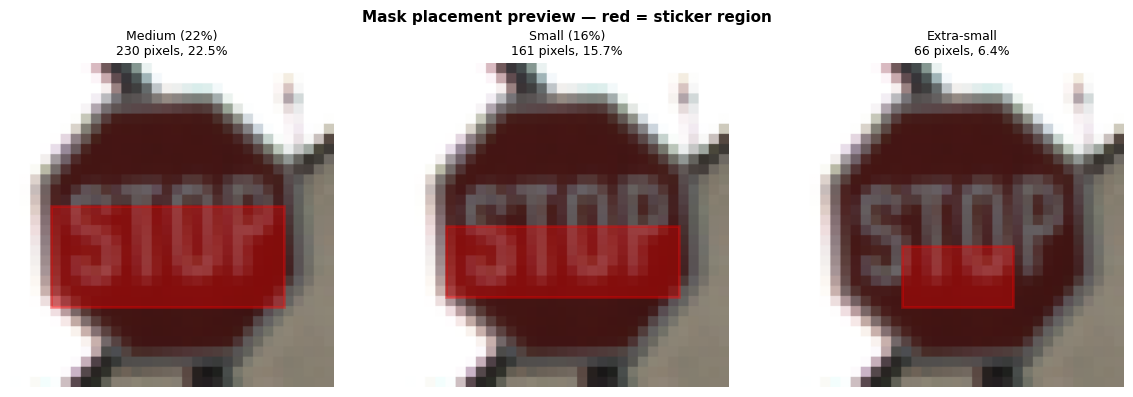


Happy with placement? Adjust PATCH_XS and re-run to fine-tune.
When satisfied run the training cell.


In [23]:
# ── Extra-small mask — same height as small, half width, placed lower ─────────

# Small was: row 0.52–0.72, col 0.15–0.85
# Extra-small: same row height (0.20), half col width (0.35), centered, shifted down

col_center = (0.15 + 0.85) / 2          # = 0.50 (center of sign horizontally)
half_width = (0.85 - 0.15) / 4          # = 0.175 (quarter of full → half of small)

PATCH_XS = dict(
    row_start = 0.58,                    # shifted down from 0.52
    row_end   = 0.78,                    # same height (0.20 range)
    col_start = col_center - half_width, # 0.325
    col_end   = col_center + half_width, # 0.675
)

mask_xs, (r0_xs, r1_xs, c0_xs, c1_xs) = build_custom_mask(
    CFG["image_size"], **PATCH_XS
)
mask_xs = mask_xs.to(CFG["device"])

print(f"Mask comparison:")
print(f"  Small       : row 0.52–0.72, col 0.15–0.85 → {int(mask_small.sum())} px, {mask_small.mean()*100:.1f}%")
print(f"  Extra-small : row {PATCH_XS['row_start']}–{PATCH_XS['row_end']}, "
      f"col {PATCH_XS['col_start']:.3f}–{PATCH_XS['col_end']:.3f} "
      f"→ {int(mask_xs.sum())} px, {mask_xs.mean()*100:.1f}%")

# ── Visualise all three masks side by side ────────────────────────────────────
scale = 6
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Mask placement preview — red = sticker region",
             fontsize=11, fontweight="bold")

masks_to_show = [
    ("Medium (22%)",    mask_final, 14, 24,    4, 27),
    ("Small (16%)",     mask_small, 16, 23,    4, 27),
    ("Extra-small",     mask_xs,    r0_xs, r1_xs, c0_xs, c1_xs),
]

for ax, (label, m, r0, r1, c0, c1) in zip(axes, masks_to_show):
    img, _ = dataset[source_indices[0]]
    img_up = np.repeat(np.repeat(
        denorm(img).permute(1,2,0).numpy(), scale, 0), scale, 1)
    ax.imshow(img_up)
    rect = mpatches.Rectangle(
        (c0 * scale, r0 * scale),
        (c1 - c0) * scale,
        (r1 - r0) * scale,
        linewidth=2, edgecolor="red",
        facecolor="red", alpha=0.35
    )
    ax.add_patch(rect)
    ax.set_title(f"{label}\n{int(m.sum())} pixels, {m.mean()*100:.1f}%", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\nHappy with placement? Adjust PATCH_XS and re-run to fine-tune.")
print("When satisfied run the training cell.")

Mask: rows 14–24, cols 4–28 → 240 px | 23.4% coverage
Mask: rows 16–23, cols 4–27 → 161 px | 15.7% coverage
Mask: rows 19–26, cols 10–22 → 84 px | 8.2% coverage


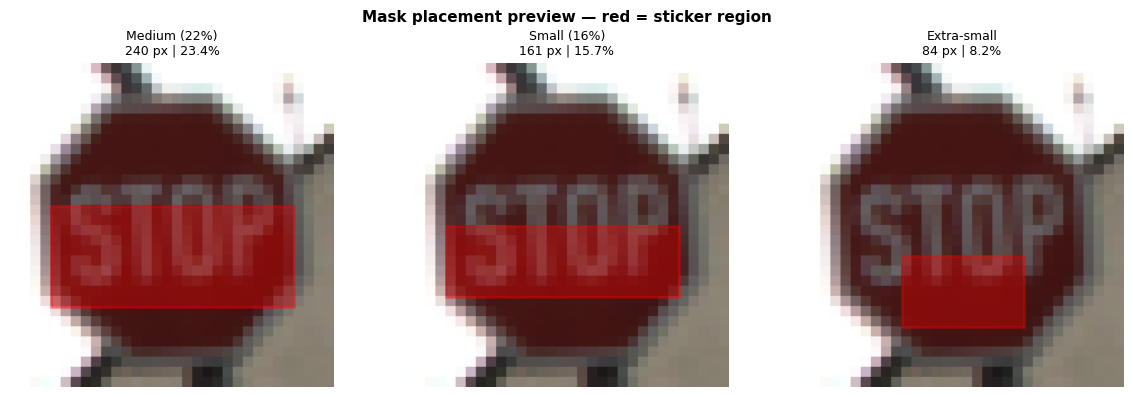

In [24]:
# ── Fix: define extra-small directly in pixel coordinates ─────────────────────
# 32×32 image
# Small was: rows 16–23 (7px tall), cols 4–27 (23px wide) = 161px
# Extra-small: same height (7px), half width (~11px), centered, shifted lower

# Center col of sign = 32//2 = 16
# Half width of small = 23//2 = 11 or 12px
# So cols: 16 - 6 = 10  to  16 + 6 = 22  (12px wide)
# Shift lower: rows 19–26 instead of 16–23

def build_mask_pixels(image_size, r0, r1, c0, c1):
    """Build mask directly from pixel coordinates."""
    mask = torch.zeros(1, image_size, image_size)
    mask[:, r0:r1, c0:c1] = 1.0
    print(f"Mask: rows {r0}–{r1}, cols {c0}–{c1} "
          f"→ {(r1-r0)*(c1-c0)} px | {mask.mean()*100:.1f}% coverage")
    return mask

# Define all three masks in pixel coords for apples-to-apples comparison
masks_config = {
    "Medium (22%)" : (14, 24,  4, 28),   # rows 14–24, cols 4–28
    "Small (16%)"  : (16, 23,  4, 27),   # rows 16–23, cols 4–27
    "Extra-small"  : (19, 26, 10, 22),   # rows 19–26, cols 10–22 — centered, lower
}

built_masks = {}
for label, (r0, r1, c0, c1) in masks_config.items():
    m = build_mask_pixels(CFG["image_size"], r0, r1, c0, c1)
    built_masks[label] = (m, r0, r1, c0, c1)

# ── Visualise ─────────────────────────────────────────────────────────────────
scale = 6
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Mask placement preview — red = sticker region",
             fontsize=11, fontweight="bold")

for ax, (label, (m, r0, r1, c0, c1)) in zip(axes, built_masks.items()):
    img, _ = dataset[source_indices[0]]
    img_up = np.repeat(np.repeat(
        denorm(img).permute(1,2,0).numpy(), scale, 0), scale, 1)
    ax.imshow(img_up)
    rect = mpatches.Rectangle(
        (c0 * scale, r0 * scale),
        (c1 - c0) * scale,
        (r1 - r0) * scale,
        linewidth=2, edgecolor="red",
        facecolor="red", alpha=0.35
    )
    ax.add_patch(rect)
    ax.set_title(f"{label}\n{int(m.sum())} px | {m.mean()*100:.1f}%", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Assign mask_xs for training
mask_xs, *_ = built_masks["Extra-small"]
mask_xs = mask_xs.to(CFG["device"])

Mask: rows 14–24, cols 4–28 → 240 px | 23.4% coverage
Mask: rows 16–23, cols 4–27 → 161 px | 15.7% coverage
Mask: rows 20–24, cols 10–22 → 48 px | 4.7% coverage


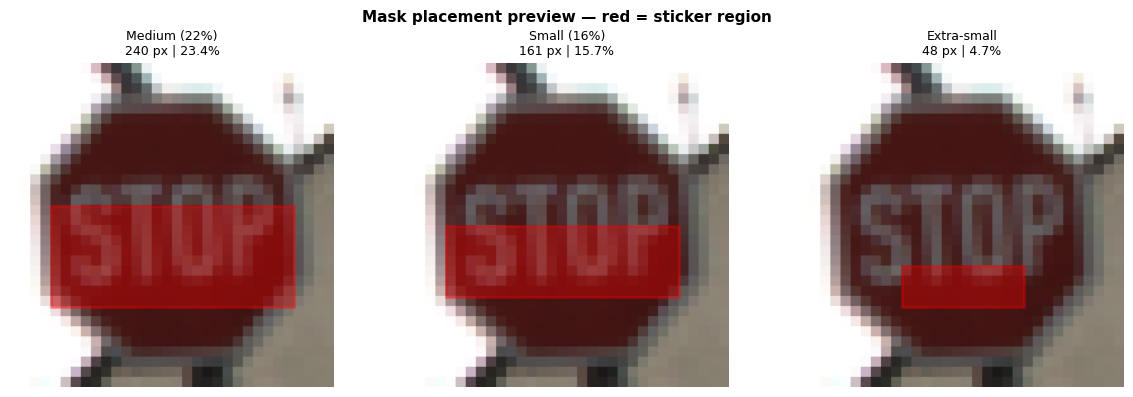

In [25]:
# Thinner extra-small — reduce height from 7px to 4px
masks_config = {
    "Medium (22%)" : (14, 24,  4, 28),
    "Small (16%)"  : (16, 23,  4, 27),
    "Extra-small"  : (20, 24, 10, 22),   # 4px tall instead of 7px, same col position
}

built_masks = {}
for label, (r0, r1, c0, c1) in masks_config.items():
    m = build_mask_pixels(CFG["image_size"], r0, r1, c0, c1)
    built_masks[label] = (m, r0, r1, c0, c1)

# Visualise
scale = 6
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Mask placement preview — red = sticker region",
             fontsize=11, fontweight="bold")

for ax, (label, (m, r0, r1, c0, c1)) in zip(axes, built_masks.items()):
    img, _ = dataset[source_indices[0]]
    img_up = np.repeat(np.repeat(
        denorm(img).permute(1,2,0).numpy(), scale, 0), scale, 1)
    ax.imshow(img_up)
    rect = mpatches.Rectangle(
        (c0 * scale, r0 * scale),
        (c1 - c0) * scale,
        (r1 - r0) * scale,
        linewidth=2, edgecolor="red",
        facecolor="red", alpha=0.35
    )
    ax.add_patch(rect)
    ax.set_title(f"{label}\n{int(m.sum())} px | {m.mean()*100:.1f}%", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Assign for training
mask_xs, *_ = built_masks["Extra-small"]
mask_xs = mask_xs.to(CFG["device"])

In [ ]:
# ── MAX_L2 sweep on extra-small mask ─────────────────────────────────────────

max_l2_values = [16.0, 20.0]
sweep_results_xs = {}

for max_l2 in max_l2_values:
    print(f"\nTraining extra-small | MAX_L2={max_l2} ...")

    d   = (torch.rand_like(all_source_imgs[0]) * 2 - 1) * 0.05 * mask_xs
    d   = d.detach().requires_grad_(True)
    opt = torch.optim.Adam([d], lr=0.01)

    for step in range(500):
        opt.zero_grad()
        total_loss = torch.tensor(0.0, device=CFG["device"])
        n = 0
        for x_i in all_source_imgs:
            for _ in range(CFG["num_transforms"]):
                x_t = sampler(x_i + mask_xs * d)
                total_loss += criterion(model(x_t.unsqueeze(0)), target)
                n += 1
        loss  = total_loss / n
        loss += lambda_tv * tv_loss(mask_xs * d)
        loss += lambda_lp * (mask_xs * d).norm(p=2)
        loss.backward()
        opt.step()
        with torch.no_grad():
            d.data = project_l2(d.data, mask_xs, max_l2=max_l2)

        if (step + 1) % 100 == 0:
            with torch.no_grad():
                hits = sum(
                    int(model((x_i + mask_xs * d).unsqueeze(0)
                        ).argmax(1).item() == CFG["target_class"])
                    for x_i in all_source_imgs
                )
            print(f"  step {step+1} | ASR={hits/len(all_source_imgs):.0%} | "
                  f"L2={(mask_xs * d).norm(p=2).item():.2f}")

    # Final evaluation
    with torch.no_grad():
        clean_hits = sum(
            int(model((x_i + mask_xs * d).unsqueeze(0)
                ).argmax(1).item() == CFG["target_class"])
            for x_i in all_source_imgs
        )
        robust_hits, robust_total = 0, 0
        for x_i in all_source_imgs:
            for _ in range(10):
                x_t = sampler(x_i + mask_xs * d)
                robust_hits  += int(model(x_t.unsqueeze(0)).argmax(1).item() == CFG["target_class"])
                robust_total += 1

    clean_asr  = clean_hits / len(all_source_imgs)
    robust_asr = robust_hits / robust_total
    max_shift  = (mask_xs * d).abs().max().item()

    sweep_results_xs[max_l2] = dict(
        d          = d.detach().clone(),
        clean_asr  = clean_asr,
        robust_asr = robust_asr,
        max_shift  = max_shift,
    )
    print(f"  DONE | clean={clean_asr:.0%} | robust={robust_asr:.0%} | "
          f"max_shift={max_shift:.3f} | pixels={int(mask_xs.sum())}")

# ── Summary table — all mask sizes together ───────────────────────────────────
print(f"\n{'='*70}")
print(f"  Full comparison — all mask sizes")
print(f"{'='*70}")
print(f"  {'Mask':>15}  {'Pixels':>7}  {'MAX_L2':>7}  {'Clean':>7}  {'Robust':>8}")
print(f"  {'-'*55}")

# Reference results from earlier
print(f"  {'Medium':>15}  {'230':>7}  {'8.0':>7}  {'~93%':>7}  {'~90%':>8}")
print(f"  {'Small':>15}  {'161':>7}  {'8.0':>7}  {'~83%':>7}  {'~80%':>8}")
print(f"  {'-'*55}")
for max_l2, r in sweep_results_xs.items():
    print(f"  {'Extra-small':>15}  {int(mask_xs.sum()):>7}  {max_l2:>7.1f}  "
          f"{r['clean_asr']:>7.0%}  {r['robust_asr']:>8.0%}")

# ── Visualise patches at different L2 budgets ─────────────────────────────────
fig, axes = plt.subplots(2, len(max_l2_values), figsize=(14, 6))
fig.suptitle(f"Extra-small mask ({int(mask_xs.sum())} px, {mask_xs.mean()*100:.1f}%) "
             f"— patch appearance vs MAX_L2",
             fontsize=11, fontweight="bold")

with torch.no_grad():
    for col, (max_l2, r) in enumerate(sweep_results_xs.items()):
        # Row 0: patch appearance
        patch_vis = denorm(mask_xs.cpu() * r["d"].cpu() * 3 + 0.5).squeeze()
        axes[0, col].imshow(np.repeat(np.repeat(
            patch_vis.permute(1,2,0).numpy(), 6, 0), 6, 1))
        axes[0, col].set_title(
            f"MAX_L2={max_l2}\nclean={r['clean_asr']:.0%} robust={r['robust_asr']:.0%}",
            fontsize=8)
        axes[0, col].axis("off")

        # Row 1: patch on real stop sign
        img, _ = dataset[source_indices[0]]
        img    = img.to(CFG["device"])
        x_adv  = img + mask_xs * r["d"].to(CFG["device"])
        pred   = model(x_adv.unsqueeze(0)).argmax(1).item()
        axes[1, col].imshow(np.repeat(np.repeat(
            denorm(x_adv).permute(1,2,0).numpy(), 6, 0), 6, 1))
        axes[1, col].set_title(
            f"pred={GTSRB_CLASSES[pred][:12]}\n{'✓' if pred==CFG['target_class'] else '✗'}",
            fontsize=8,
            color="green" if pred==CFG["target_class"] else "red"
        )
        axes[1, col].axis("off")

plt.tight_layout()
plt.show()

# Save all
os.makedirs("./patches", exist_ok=True)
for max_l2, r in sweep_results_xs.items():
    torch.save({
        "delta"       : r["d"].cpu(),
        "mask"        : mask_xs.cpu(),
        "MAX_L2"      : max_l2,
        "clean_asr"   : r["clean_asr"],
        "robust_asr"  : r["robust_asr"],
        "source_class": CFG["source_class"],
        "target_class": CFG["target_class"],
    }, f"./patches/rp2_xs_maxl2_{int(max_l2)}.pt")

print("\n✓ All extra-small patches saved")


Training extra-small | MAX_L2=16.0 ...
  step 100 | ASR=45% | L2=7.92
  step 200 | ASR=53% | L2=9.95
  step 300 | ASR=56% | L2=10.94
  step 400 | ASR=59% | L2=11.58
  step 500 | ASR=60% | L2=12.09
  DONE | clean=60% | robust=56% | max_shift=2.496 | pixels=48

Training extra-small | MAX_L2=20.0 ...
  step 100 | ASR=43% | L2=7.87
  step 200 | ASR=52% | L2=9.81
